In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Adjust the path if your file is in a different folder within 'My Drive'
file_path = '/content/drive/My Drive/Bank-Customer-Churn-Prediction.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully! Head of the dataset:")
    print(df.head())
    print("\nDataset Info:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")


Dataset loaded successfully! Head of the dataset:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 en

### 1. Data Preprocessing

First, we'll drop columns that are not relevant for predicting customer churn, such as `customer_id`.

In [ ]:
df_preprocessed = df.copy()

# Drop customer_id as it's an identifier and not useful for prediction
df_preprocessed = df_preprocessed.drop('customer_id', axis=1)

print("DataFrame after dropping 'customer_id':")
print(df_preprocessed.head())


DataFrame after dropping 'customer_id':
   credit_score country  gender  age  tenure    balance  products_number  \
0           619  France  Female   42       2       0.00                1   
1           608   Spain  Female   41       1   83807.86                1   
2           502  France  Female   42       8  159660.80                3   
3           699  France  Female   39       1       0.00                2   
4           850   Spain  Female   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0          93826.63      0  
4            1              1          79084.10      0  


Next, we'll handle categorical features such as `country` and `gender` by converting them into numerical representations using one-hot encoding. This is necessary because most machine learning algorithms require numerical input.

In [ ]:
# One-hot encode 'country' and 'gender' columns
df_preprocessed = pd.get_dummies(df_preprocessed, columns=['country', 'gender'], drop_first=True)

print("\nDataFrame after one-hot encoding categorical features:")
print(df_preprocessed.head())



DataFrame after one-hot encoding categorical features:
   credit_score  age  tenure    balance  products_number  credit_card  \
0           619   42       2       0.00                1            1   
1           608   41       1   83807.86                1            0   
2           502   42       8  159660.80                3            1   
3           699   39       1       0.00                2            0   
4           850   43       2  125510.82                1            1   

   active_member  estimated_salary  churn  country_Germany  country_Spain  \
0              1         101348.88      1            False          False   
1              1         112542.58      0            False           True   
2              0         113931.57      1            False          False   
3              0          93826.63      0            False          False   
4              1          79084.10      0            False           True   

   gender_Male  
0        False  
1       

Now, we will separate the features (X) from the target variable (y), which is `churn`. Then, we will scale the numerical features to ensure that no single feature dominates the learning process due to its magnitude.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df_preprocessed.drop('churn', axis=1)
y = df_preprocessed['churn']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame with original column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFeatures (X) after scaling:")
print(X_scaled.head())



Features (X) after scaling:
   credit_score       age    tenure   balance  products_number  credit_card  \
0     -0.326221  0.293517 -1.041760 -1.225848        -0.911583     0.646092   
1     -0.440036  0.198164 -1.387538  0.117350        -0.911583    -1.547768   
2     -1.536794  0.293517  1.032908  1.333053         2.527057     0.646092   
3      0.501521  0.007457 -1.387538 -1.225848         0.807737    -1.547768   
4      2.063884  0.388871 -1.041760  0.785728        -0.911583     0.646092   

   active_member  estimated_salary  country_Germany  country_Spain  \
0       0.970243          0.021886        -0.578736      -0.573809   
1       0.970243          0.216534        -0.578736       1.742740   
2      -1.030670          0.240687        -0.578736      -0.573809   
3      -1.030670         -0.108918        -0.578736      -0.573809   
4       0.970243         -0.365276        -0.578736       1.742740   

   gender_Male  
0    -1.095988  
1    -1.095988  
2    -1.095988  
3    -1

Finally, we split the data into training and testing sets. This is crucial for evaluating the performance of our classification model on unseen data.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


### 2. Classification Model: Logistic Regression

We will now use Logistic Regression, a widely used algorithm for binary classification, to predict customer churn. After training the model, we'll evaluate its performance using key metrics like accuracy, precision, recall, and F1-score.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


Now, let's make predictions on the test set and evaluate the model's performance.


Model Evaluation (Logistic Regression):
Accuracy: 0.8080
Precision: 0.5891
Recall: 0.1867
F1-Score: 0.2836

Confusion Matrix:
[[1540   53]
 [ 331   76]]


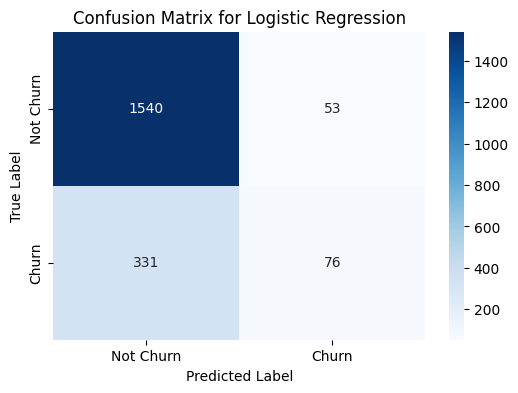

In [ ]:
# Make predictions on the scaled test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Evaluation (Logistic Regression):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Optional: Visualize Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 3. Classification Model: Decision Tree Classifier

Now, let's explore another common classification algorithm: the Decision Tree. We'll train a Decision Tree model on our preprocessed data and then evaluate its performance similar to the Logistic Regression model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Decision Tree Classifier model
# You can tune hyperparameters like 'max_depth' or 'min_samples_leaf' for better performance
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully!")


Decision Tree Classifier model trained successfully!


Let's make predictions on the test set and evaluate the Decision Tree model's performance.


Model Evaluation (Decision Tree Classifier):
Accuracy: 0.7840
Precision: 0.4719
Recall: 0.5160
F1-Score: 0.4930

Confusion Matrix (Decision Tree Classifier):
[[1358  235]
 [ 197  210]]


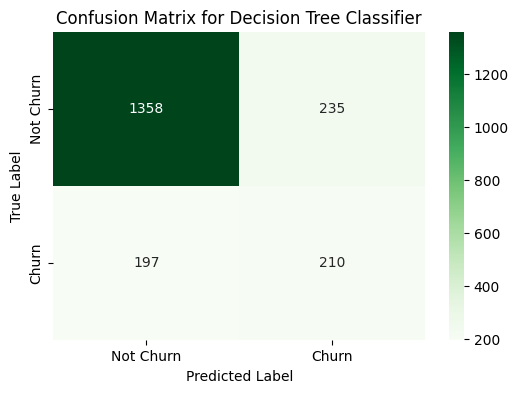

In [ ]:
# Make predictions on the scaled test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"\nModel Evaluation (Decision Tree Classifier):")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Display Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree Classifier):")
print(conf_matrix_dt)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


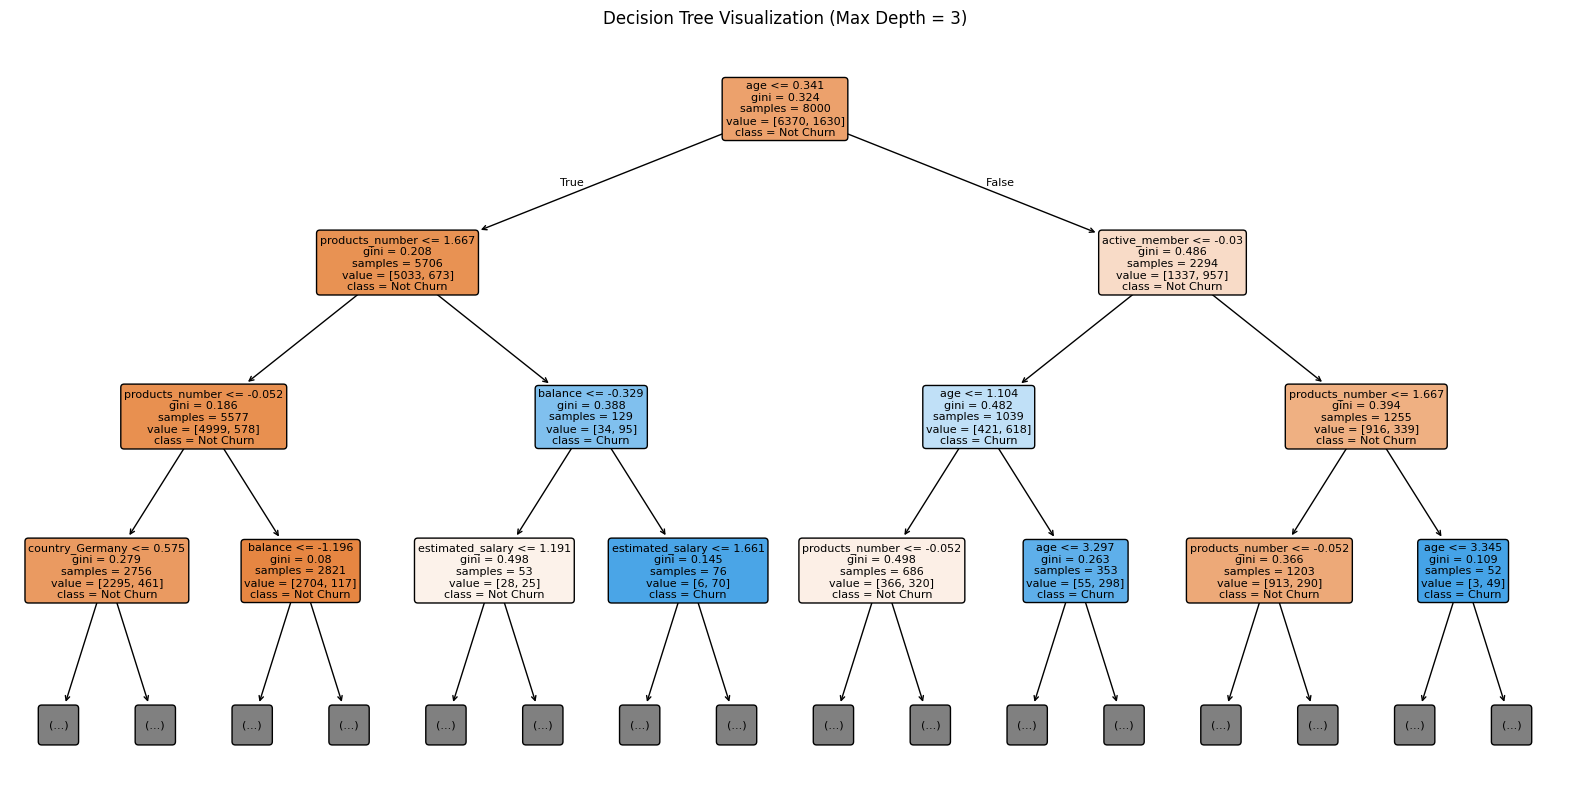

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize a portion of the Decision Tree (limiting depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model,
          feature_names=X.columns.tolist(), # Use original feature names from X
          class_names=['Not Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limit depth to 3 for better visualization
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()

This chart visualizes the structure of the Decision Tree. Due to the complexity of the full tree, I've limited the `max_depth` to 3 for better readability. Each node represents a decision rule based on a feature, leading to a classification of 'Not Churn' or 'Churn' at the leaf nodes.

### Logistic Regression: Feature Coefficients

For Logistic Regression, we can visualize the coefficients assigned to each feature. The magnitude of these coefficients indicates the strength and direction of the feature's influence on the churn prediction. A larger absolute value means a stronger impact.

/tmp/ipykernel_4134/1282568342.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


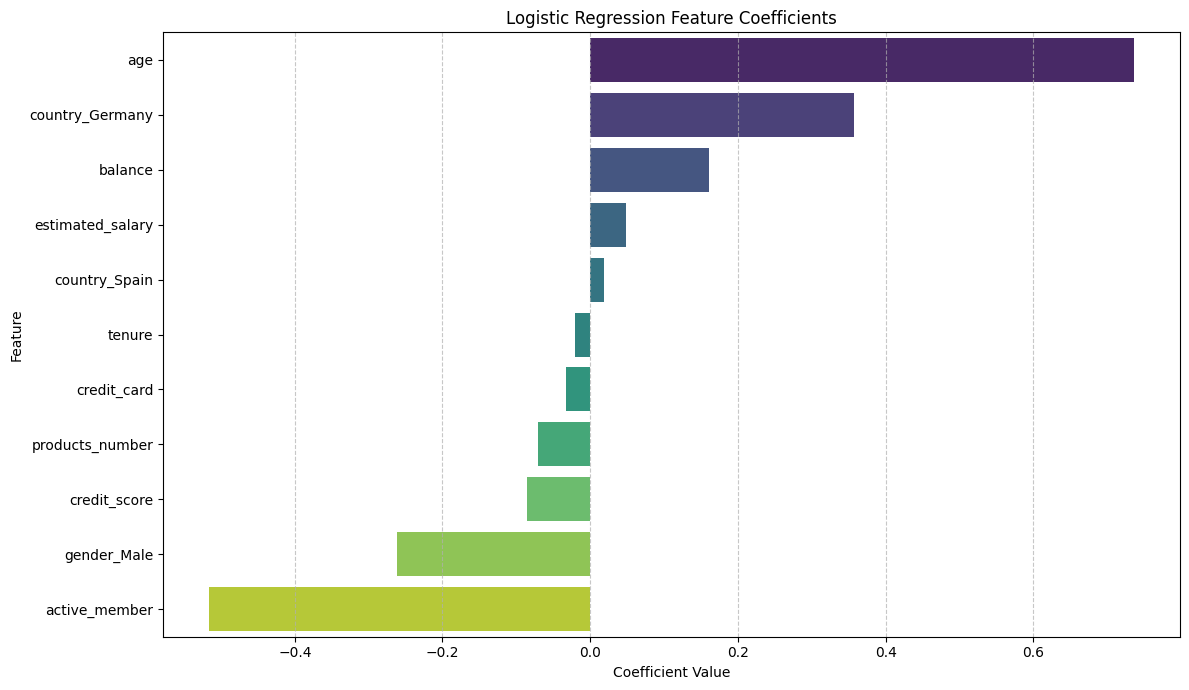

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get coefficients and feature names
coefficients = log_reg_model.coef_[0]
feature_names = X_train.columns

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Next, let's visualize the feature importances for the Random Forest model.

### 4. Classification Model: Random Forest Classifier

Let's move on to the Random Forest Classifier. This is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest Classifier model
# You can tune hyperparameters like 'n_estimators', 'max_depth', etc.
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully!")


Random Forest Classifier model trained successfully!


Now, let's make predictions on the test set and evaluate the Random Forest model's performance.


Model Evaluation (Random Forest Classifier):
Accuracy: 0.8645
Precision: 0.7833
Recall: 0.4619
F1-Score: 0.5811

Confusion Matrix (Random Forest Classifier):
[[1541   52]
 [ 219  188]]


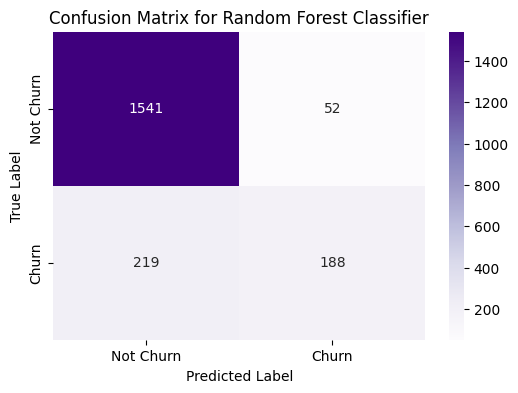

In [ ]:
# Make predictions on the scaled test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\nModel Evaluation (Random Forest Classifier):")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Display Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Random Forest Classifier):")
print(conf_matrix_rf)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Random Forest: Feature Importances

Random Forests provide a measure of feature importance, indicating how much each feature contributes to the prediction accuracy. A higher importance score means the feature is more influential in determining churn.

/tmp/ipykernel_4134/2558228123.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


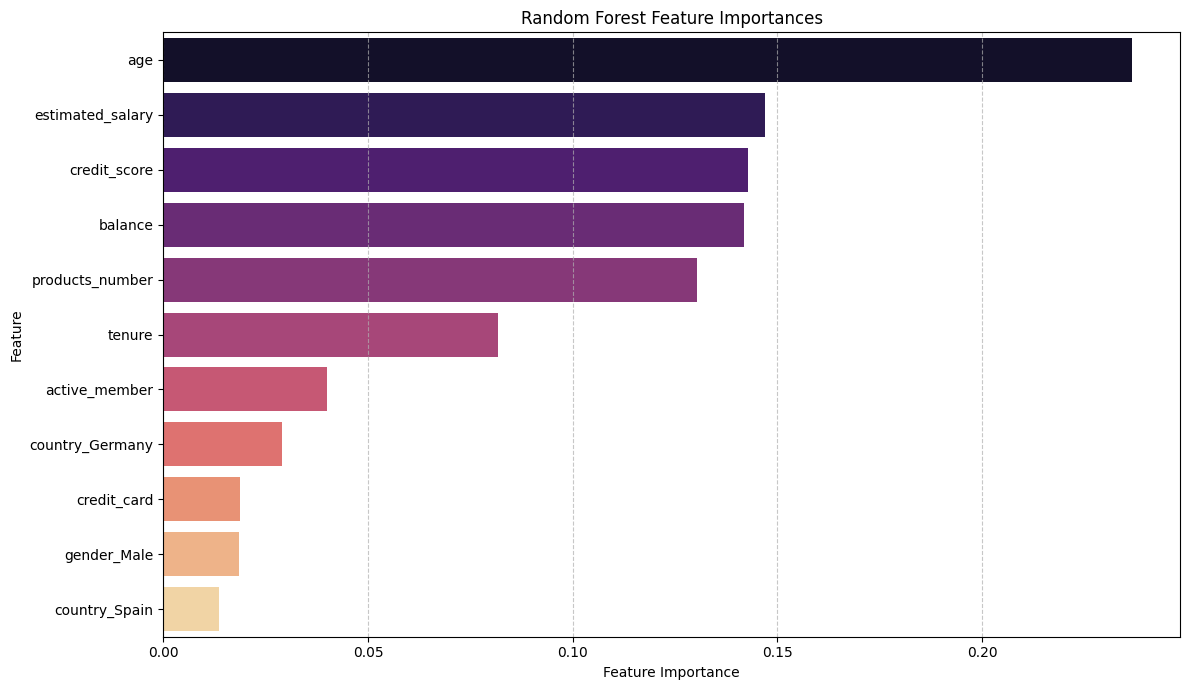

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained Random Forest model
importances = random_forest_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()